In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [2]:
seed = 42

root_path = "/home/stefan/ioai-prep/kits/dataset-774fcbed-cc09-42ce-b4c2-88d788ec8703"

# Data

In [3]:
df = pd.read_csv(f"{root_path}/train.csv")
df_train = df.drop(["SampleID", "target"], axis=1)
y = df["target"]

<Axes: xlabel='target'>

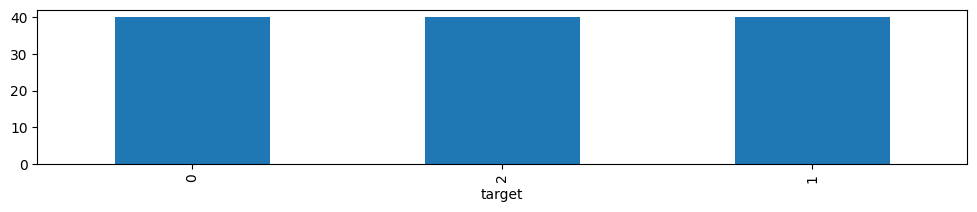

In [4]:
plt.figure(figsize=(12, 2))
df["target"].value_counts().plot(kind="bar")

# Model

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df_train, y, test_size=0.2, random_state=seed, stratify=y
)

In [6]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, scoring="f1_macro", cv=3, n_jobs=-1)
    cv_score = cv.mean()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = f1_score(y_test, preds, average="macro")

    return cv_score, score

In [7]:
logreg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=seed)),
    ]
)
evaluate(logreg)

(np.float64(0.9585370981251988), 0.9581699346405229)

In [8]:
xgb = XGBClassifier(random_state=seed, n_jobs=-1)
evaluate(xgb)

(np.float64(0.9580630319760753), 0.9581699346405229)

In [9]:
model = xgb
model.fit(df_train, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

# Submission

In [10]:
df_test = pd.read_csv(f"{root_path}/test.csv")
submission = df_test[["SampleID"]]

df_test = df_test.drop(["SampleID"], axis=1)

In [11]:
submission["label"] = model.predict(df_test)
submission.head()

,SampleID,label
0,39,0
1,128,2
2,58,1
3,94,1
4,43,0


In [12]:
submission.to_csv(f"{root_path}/submission.csv", index=False)